# Inflow score to infer CCC in single cell level

## Background

## Load Packages

In [ ]:
!! pip install squidpy
!! pip install muon

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
from liana.method.sp._inflow import inflow

c:\Users\athee\anaconda3\envs\liana_new\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
c:\Users\athee\anaconda3\envs\liana_new\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


## Load and Prep Data

We will apply inflow score to colorectal cancer (CRC) whole-transcriptome spatial molecular imaging (WTx CosMx SMI) slide ([crowell2025tracing](https://doi.org/10.1101/2025.06.23.660674); [15574384](https://zenodo.org/records/15574384)).

In [2]:
data_list = ['110', '120', '210', '221', '231', '232', '242']
data_name = '210'

In [ ]:
adata = sc.read(
    f"../data/crc_wt_cosmx/crc_{data_name}.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/{data_list[0]}.h5ad?download=1"
)

In [25]:
adata.obs

,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68_CK8_18,...,typ,roi,ctx,trj,ist,lv1,jst,lv2,CenterX_local_um,CenterY_local_um
c_1_1_1,1,13880,2.36,1288,46,222,94,10644,54824,178,...,110_TVA2,NaN,N3,18.979312,epi4,epi,epi.3,epi.prolif,154.92064,5.53288
c_1_1_2,1,7629,1.97,1442,38,154,78,6295,14872,213,...,110_TVA2,NaN,N3,18.492518,epi4,epi,epi_LGR5,epi.stem-like_LGR5,173.44376,4.57064
c_1_1_3,1,1512,1.25,1533,23,60,48,3763,6340,205,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,184.38924,2.76644
c_1_1_4,1,2945,2.12,2526,21,91,43,3559,7740,175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.82728,2.52588
c_1_1_5,1,3328,0.99,2730,34,69,70,4773,16840,230,...,110_TVA2,NaN,N3,14.266613,epi2,epi,epi_LEFTY1,epi.stem-like_CLU,328.36440,4.08952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_1_384_1675,384,1897,1.02,1149,4230,52,51,796,1760,347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138.20172,508.78440
c_1_384_1676,384,1452,1.33,2091,4237,48,36,859,1428,1485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,251.50548,509.62636
c_1_384_1677,384,1403,1.68,120,4238,57,34,660,1200,8236,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.43360,509.74664
c_1_384_1678,384,2389,1.97,2282,4236,77,39,1127,1812,2235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.47896,509.50608


In [11]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

c:\Users\athee\anaconda3\envs\liana_new\lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: Some cells have zero counts


## Calculate spatial connectivity matrix Wij

Change bandwidth value based on the spatial resolution of your data (e.g., spot size in Visium = 55 µm).

In [26]:
# Convert mm to um using global coordinates
adata.obs['CenterX_um'] = adata.obs['CenterX_global_mm'] * 1000
adata.obs['CenterY_um'] = adata.obs['CenterY_global_mm'] * 1000

In [27]:
#Extract coords and save them in obsm["spatial"], li.ut.spatial_neighbors() and squidpy functions like sq.gr.spatial_autocorr() look for spatial coordinates in adata.obsm["spatial"] by default.
coords = adata.obs[['CenterX_um', 'CenterY_um']].to_numpy()
adata.obsm["spatial"] = coords

In [29]:
li.ut.spatial_neighbors(adata=adata, bandwidth=50)

In [30]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False)

c:\Users\athee\anaconda3\envs\liana_new\lib\site-packages\scanpy\metrics\_morans_i.py:105: UserWarning: 1 variables were constant, will return nan for these.


In [31]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
OLFM4,0.515671,0.000000,3.034082e-08,NaN
KRT8,0.441478,0.000000,3.034082e-08,NaN
S100A6,0.397489,0.000000,3.034082e-08,NaN
TMSB10,0.389938,0.000000,3.034082e-08,NaN
LYZ,0.387261,0.000000,3.034082e-08,NaN
...,...,...,...,...
KRT1,0.000494,0.002244,3.034082e-08,NaN
RNF180,0.000492,0.002304,3.034082e-08,NaN
ZNF829,0.000473,0.003237,3.034082e-08,NaN
PRDM9,0.000400,0.010613,3.034082e-08,NaN


In [33]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

3465

## Option1: filter by SVGs 

Filtering your adata by SVGs (Spatially Variable Genes) means selecting only those LR interactions where BOTH the ligand and the receptor genes show spatial variability.
<br>

Keep in mind that applying this filter may reduce the number of detected LR pairs, possibly excluding biologically meaningful interactions where only one partner is spatially variable.
<br>

In this tutorial, we will use this filter for faster calculations
</br>

In [34]:
adata = adata[:, svgs]

## Option2: filter by SVGs and their pair

This option filters out ligand–receptor (LR) pairs only when neither the ligand nor the receptor is spatially variable.

In [ ]:
#retrive LR database
lr = li.rs.select_resource()
ligand_set = set(lr['ligand']) #1027
receptor_set = set(lr['receptor']) #1052

In [ ]:
svgs_df = adata.uns['moranI'][(adata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (adata.uns['moranI']['I'] > 0.01)]

In [ ]:
sorted_filtered = svgs_df.reset_index().rename(columns={'index': 'gene'})

# Create lookup dictionary for faster access
moran_dict = dict(zip(sorted_filtered['gene'], sorted_filtered['I']))

# Map Moran's I values to ligand and receptor
lr['ligand_moran_I'] = lr['ligand'].map(moran_dict)
lr['receptor_moran_I'] = lr['receptor'].map(moran_dict)

In [ ]:
lr_filtered = lr[~(lr['ligand_moran_I'].isna() & lr['receptor_moran_I'].isna())]

In [ ]:
genes_to_keep = np.unique(
    lr_filtered['ligand'].unique().tolist() + 
    lr_filtered['receptor'].unique().tolist()
)

In [ ]:
adata_filtered = adata[:, adata.var_names.isin(genes_to_keep)].copy()

## Compute inflow score 

In [5]:
global_res, lrdata = inflow(adata,  
                                  groupby='ist', # cell type columns
                                  resource_name='cellchatdb',
                                  use_raw=False)
                                  
lrdata.shape

c:\Users\athee\anaconda3\envs\liana_new\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
h:\Other computers\My Laptop (1)\Google Drive\PhD_project\Spatial_and_CCC_with_Daniel\liana-py\docs\source\notebooks\inflow_score_test.py:209: RuntimeWarning: divide by zero encountered in divide


(694553, 1830)

In [6]:
# Summed by the cell types (this is tetravariate essentially)
global_res.sort_values('value').tail() # NOTE: should correspond to the most commonly expressed (by cell type)

,name,value
9792,epi4^APP^CD74^epi4,0.393893
15038,epi2^APP^CD74^mye1,0.598055
15282,epi4^APP^CD74^mye1,0.619736
9879,epi4^CEACAM1^CEACAM5^epi4,0.654492
4023,epi1^CEACAM1^CEACAM5^epi1,0.861901


## Optional: filter data to keep only spatially variable LR interaction

In [11]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

c:\Users\athee\anaconda3\envs\liana_new\lib\site-packages\squidpy\gr\_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [12]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]

In [13]:
len(svis)

1509

In [14]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
epi4^APP^CD74,0.309099,0.0,3.034082e-08,0.0
mye1^CEACAM1^CEACAM5,0.309986,0.0,3.034082e-08,0.0
fib2^CEACAM1^CEACAM5,0.335971,0.0,3.034082e-08,0.0
epi3^APP^CD74,0.359729,0.0,3.034082e-08,0.0
epi4^ADGRE5^CD55,0.369311,0.0,3.034082e-08,0.0
epi4^MDK^NCL,0.387027,0.0,3.034082e-08,0.0
epi2^CEACAM1^CEACAM5,0.401616,0.0,3.034082e-08,0.0
epi3^CEACAM1^CEACAM5,0.427291,0.0,3.034082e-08,0.0
epi1^CEACAM1^CEACAM5,0.507733,0.0,3.034082e-08,0.0
epi4^CEACAM1^CEACAM5,0.583381,0.0,3.034082e-08,0.0


## Plot layout of chosen interactions

In [15]:
adata.layers['transformed'] = li.utils.zi_minmax(adata.X, cutoff=0.01)

C:\Users\athee\AppData\Local\Temp\ipykernel_25272\2455406758.py:19: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
C:\Users\athee\AppData\Local\Temp\ipykernel_25272\2455406758.py:21: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
C:\Users\athee\AppData\Local\Temp\ipykernel_25272\2455406758.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
C:\Users\athee\AppData\Local\Temp\ipykernel_25272\2455406758.py:25: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
C:\Users\athee\AppData\Local\Temp\ipykernel_25272\2455406758.py:27: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
C:\Users\athee\AppData\Local\Temp\ipykernel_25272\2455406758.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


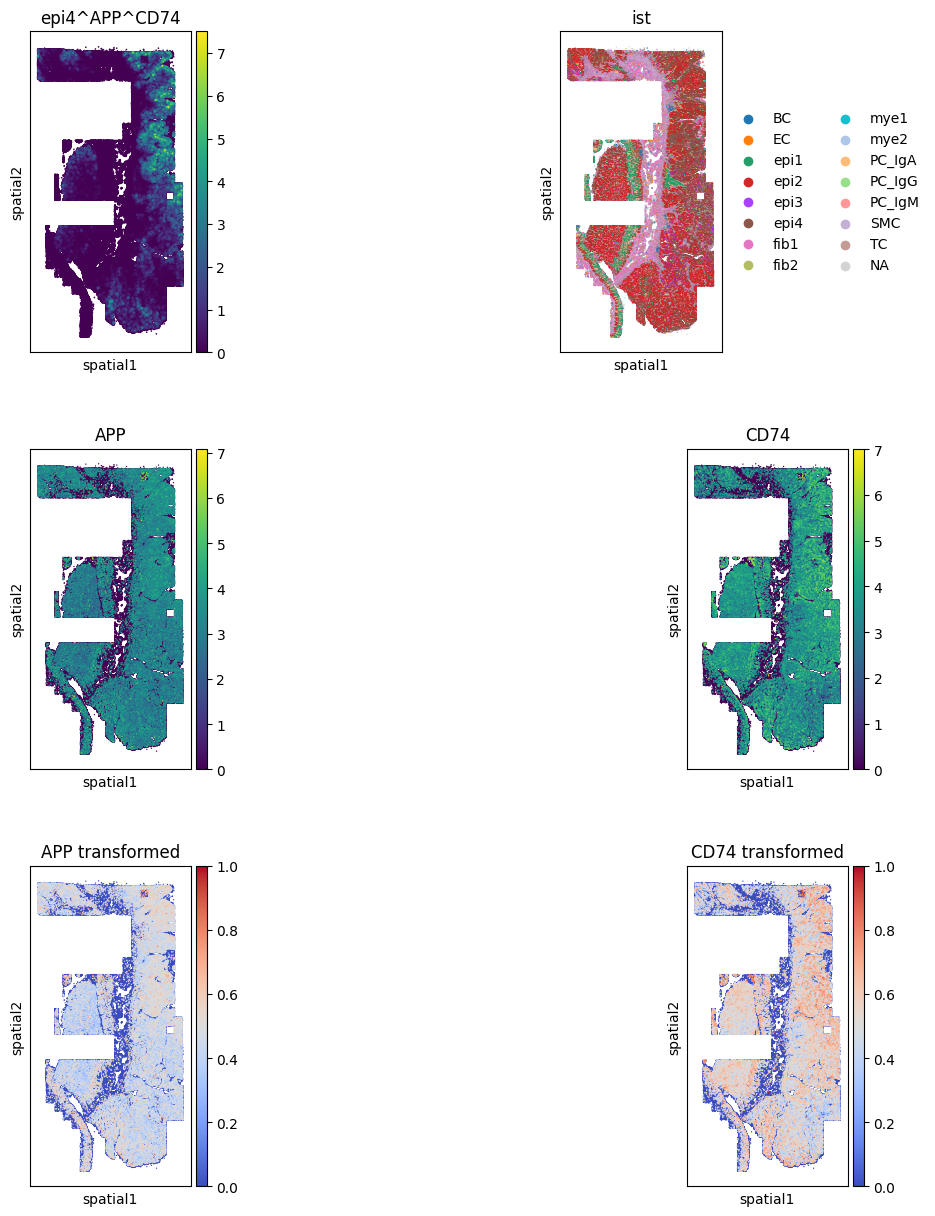

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

# Define your keys
key = 'epi4^APP^CD74' #NOTE @Moeed, sanity check interaction for Macrophage infiltration
xy_sep = '^'
groupby = 'ist'
keys = key.split(xy_sep)

if len(keys) < 2:
    raise ValueError("The 'key' variable should contain at least two elements separated by '&'.")

ligand = keys[1]
receptor = keys[2]

adata.obs['receptor'] = (adata[:, receptor].X > 0).toarray().flatten()

sc.pl.spatial(lrdata, color=[key], spot_size=100, ax=axes[0],show=False)
axes[0].set_title(f"{key}")
sc.pl.spatial(adata, color=[groupby], spot_size=80, ax=axes[1],show=False)
axes[1].set_title(f"{groupby}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[2], show=False)
axes[2].set_title(f"{ligand}")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[3], show=False)
axes[3].set_title(f"{receptor}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[4], show=False, layer='transformed', cmap='coolwarm')
axes[4].set_title(f"{ligand} transformed")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[5], show=False, layer='transformed', cmap='coolwarm')
axes[5].set_title(f"{receptor} transformed")
plt.show()